In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx

In [2]:
df = pd.read_csv('feature_data.csv')

# 1. Basic Data Structure Exploration 

In [3]:
df.columns

Index(['location_block', 'day_of_week', 'time_band_label', 'season',
       'n_opportunities', 'k_ticketed', 'total_tickets', 'raw_recurrence_rate',
       'prior_mean', 'alpha', 'beta', 'posterior_recurrence_score',
       'clean_location_block', 'LOCATION', 'enforcement_grade', 'ZCTA',
       'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588730 entries, 0 to 1588729
Data columns (total 18 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   location_block              1588730 non-null  object 
 1   day_of_week                 1588730 non-null  object 
 2   time_band_label             1588730 non-null  object 
 3   season                      1588730 non-null  object 
 4   n_opportunities             1588730 non-null  int64  
 5   k_ticketed                  1588730 non-null  int64  
 6   total_tickets               1588730 non-null  int64  
 7   raw_recurrence_rate         1588730 non-null  float64
 8   prior_mean                  1588730 non-null  float64
 9   alpha                       1588730 non-null  float64
 10  beta                        1588730 non-null  float64
 11  posterior_recurrence_score  1588730 non-null  float64
 12  clean_location_block        1588730 non-null  object 
 1

In [5]:
df.head()

,location_block,day_of_week,time_band_label,season,n_opportunities,k_ticketed,total_tickets,raw_recurrence_rate,prior_mean,alpha,beta,posterior_recurrence_score,clean_location_block,LOCATION,enforcement_grade,ZCTA,LATITUDE,LONGITUDE
0,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Fall,13,0,0,0.0,0.003458,0.017289,4.982711,0.000960,0 BLOCK 10TH ST NE,UNIT BLOCK 10TH ST NE EAST SIDE,B,20002.0,38.89,-76.993
1,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Spring,13,0,0,0.0,0.003697,0.018483,4.981517,0.001027,0 BLOCK 10TH ST NE,UNIT BLOCK 10TH ST NE EAST SIDE,B,20002.0,38.89,-76.993
2,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Summer,13,0,0,0.0,0.002885,0.014423,4.985577,0.000801,0 BLOCK 10TH ST NE,UNIT BLOCK 10TH ST NE EAST SIDE,A,20002.0,38.89,-76.993
3,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Winter,13,0,0,0.0,0.003856,0.019279,4.980721,0.001071,0 BLOCK 10TH ST NE,UNIT BLOCK 10TH ST NE EAST SIDE,B,20002.0,38.89,-76.993
4,0 BLOCK 10TH ST NE,Friday,02:00-04:00,Fall,13,0,0,0.0,0.002483,0.012417,4.987583,0.000690,0 BLOCK 10TH ST NE,UNIT BLOCK 10TH ST NE EAST SIDE,A,20002.0,38.89,-76.993


In [6]:
df.describe()

,n_opportunities,k_ticketed,total_tickets,raw_recurrence_rate,prior_mean,alpha,beta,posterior_recurrence_score,ZCTA,LATITUDE,LONGITUDE
count,1.588730e+06,1.588730e+06,1.588730e+06,1.588730e+06,1.588730e+06,1.588730e+06,1.588730e+06,1.588730e+06,1.564538e+06,1.588730e+06,1.588730e+06
mean,1.303571e+01,6.197592e-02,1.649185e-01,4.751502e-03,3.858162e-03,1.929081e-02,4.980709e+00,4.503995e-03,2.001111e+04,3.890363e+01,-7.701016e+01
std,4.210590e-01,4.250389e-01,1.691422e+00,3.259631e-02,3.375313e-03,1.687657e-02,1.687657e-02,2.368708e-02,1.112577e+01,2.789432e-02,2.603287e-02
min,1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.414459e-05,1.207230e-04,4.927869e+00,7.101350e-06,2.000100e+04,3.881900e+01,-7.710200e+01
25%,1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.225802e-03,6.129012e-03,4.973223e+00,3.405007e-04,2.000200e+04,3.888900e+01,-7.702900e+01
50%,1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.880522e-03,1.440261e-02,4.985597e+00,8.110106e-04,2.000600e+04,3.890400e+01,-7.701000e+01
75%,1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.355323e-03,2.677662e-02,4.993871e+00,1.752915e-03,2.001900e+04,3.891400e+01,-7.699200e+01
max,1.400000e+01,1.300000e+01,2.310000e+02,1.000000e+00,1.442626e-02,7.213130e-02,4.999879e+00,7.250895e-01,2.003700e+04,3.898700e+01,-7.691400e+01


In [7]:
df.isna().sum()

location_block                     0
day_of_week                        0
time_band_label                    0
season                             0
n_opportunities                    0
k_ticketed                         0
total_tickets                      0
raw_recurrence_rate                0
prior_mean                         0
alpha                              0
beta                               0
posterior_recurrence_score         0
clean_location_block               0
LOCATION                      419328
enforcement_grade                  0
ZCTA                           24192
LATITUDE                           0
LONGITUDE                          0
dtype: int64

In [8]:
# Investigating which locations did not have a ZCTA
# Filtering for rows where ZCTA is null/NaN
missing_blocks = df[df['ZCTA'].isna()]['clean_location_block'].unique()

# Converting the filtered values to a list and sorting alphabetically
missing_blocks_list = sorted(list(missing_blocks))

# Printing results
print(f"Found {len(missing_blocks_list)} unique blocks with missing ZCTAs:\n")
for block in missing_blocks_list:
    print(f" {block}")

Found 72 unique blocks with missing ZCTAs:

 0 BLOCK 10TH ST SW
 0 BLOCK 13TH ST NW E & B
 0 BLOCK 14TH ST SW
 0 BLOCK BLOCK 6TH ST SW EAST
 0 BLOCK BLOCK F ST NW NORTH
 0 BLOCK BLOCK F ST NW SOUTH
 0 BLOCK BLOCK MARYLAND AVE SW
 0 BLOCK E ST SW
 0 BLOCK F ST NW NW & B
 0 BLOCK F ST NW SW & B
 0 BLOCK INDEPENDENCE AVE SW S
 0 BLOCK OHIO DR SW
 0 BLOCK PENNSYLVANIA AVE NW E
 0 BLOCK PENNSYLVANIA AVE NW S
 0 BLOCK SS D ST SW
 0 BLOCK T ST SW
 0 BLOCK UNIT BLOCK D ST SW
 0 BLOCK UNIT D ST SW
 0 BLOCK V ST SW SOUTH
 1 BLOCK S ST SW
 100 BLOCK 12TH ST SW
 100 BLOCK 2ND ST SE
 100 BLOCK 4TH ST NW
 100 BLOCK C ST SW
 100 BLOCK E ST SW
 100 BLOCK INDEPEDENCE AVE SE
 100 BLOCK INDEPENDENCE AVE
 100 BLOCK INDEPENDENCE AVE S
 100 BLOCK INDEPENDENCE AVE SE
 100 BLOCK INDEPENDENCE AVE SE EAST
 100 BLOCK INDEPENDENCE AVE SE N
 1000 BLOCK E ST SW
 1000 BLOCK INDEPENDENCE AVE SW
 1000 BLOCK INDEPENDENCE AVE SW N
 1000 BLOCK INDEPENDENCE AVE SW NOR
 1000 BLOCK INDEPENDENCE AVE SW S
 1000 BLOCK MAIN DR 

In [9]:
# To understand the distribution of the enforcement grades
df.groupby('enforcement_grade')[['total_tickets', 'n_opportunities', 'k_ticketed', 'raw_recurrence_rate','posterior_recurrence_score']].sum()

,total_tickets,n_opportunities,k_ticketed,raw_recurrence_rate,posterior_recurrence_score
enforcement_grade,,,,,
A,0,11075584,0,0.000000,345.422208
B,0,3323574,0,0.000000,263.860987
C,0,2623831,0,0.000000,353.141205
D,0,1717738,0,0.000000,324.962725
F,262011,1969500,98463,7548.854396,5868.244773


In [10]:
# Changing Enforcement Grade from 'F' to 'E' to preserve the chronological order
df['enforcement_grade'] = df['enforcement_grade'].replace('F', 'E')

In [11]:
# Comparing the number of blocks in a grade vs the tickets they generate
grade_comparison = df.groupby('enforcement_grade').agg(
    number_of_blocks=('clean_location_block', 'nunique'),
    total_tickets_issued=('total_tickets', 'sum')
).reset_index()

print(grade_comparison)

  enforcement_grade  number_of_blocks  total_tickets_issued
0                 A              4729                     0
1                 B              4729                     0
2                 C              4729                     0
3                 D              4726                     0
4                 E              4729                262011


# 2. Exploratory Data Analysis Using Visuals

## Analysis of Enforcement Grade

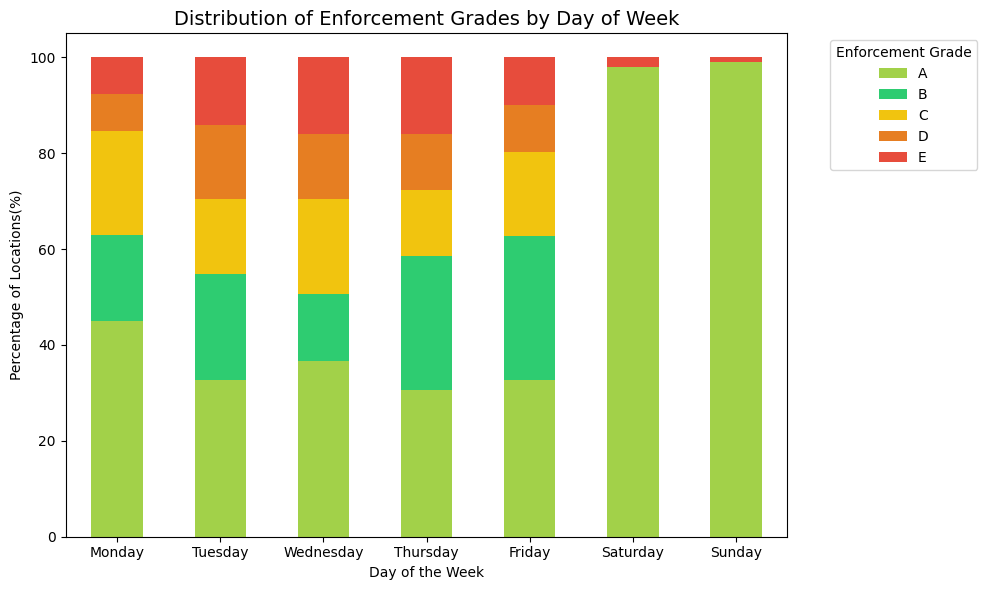

In [12]:
# PLOT: DISTRIBUTION OF ENFORCEMENT GRADES BY DAY OF WEEK
# What does the overall pattern of enforcement look in terms of day of the week and location. Are some days more prone to tickets ?

# Defining the order for days of the week to ensure the plot is chronological
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# To get the count of each enforcement grade by day_of_week
grade_counts = df.groupby(['day_of_week', 'enforcement_grade'], observed=False).size().unstack(fill_value=0)

# Setting the color palette
risk_palette = {
    'A': '#a2d149', # Light Green
    'B': '#2ecc71', # Medium Green
    'C': '#f1c40f', # Yellow
    'D': '#e67e22', # Orange
    'E': '#e74c3c'  # Red
}

# --- PLOT : Stacked Bar Chart (Proportional) ---
# Calculating the percentage of grades each day
grade_pct = grade_counts.div(grade_counts.sum(axis=1), axis=0) * 100

grade_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=[risk_palette.get(col) for col in grade_pct.columns])
plt.title('Distribution of Enforcement Grades by Day of Week', fontsize=14)
plt.ylabel('Percentage of Locations(%)')
plt.xlabel('Day of the Week')
plt.legend(title='Enforcement Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


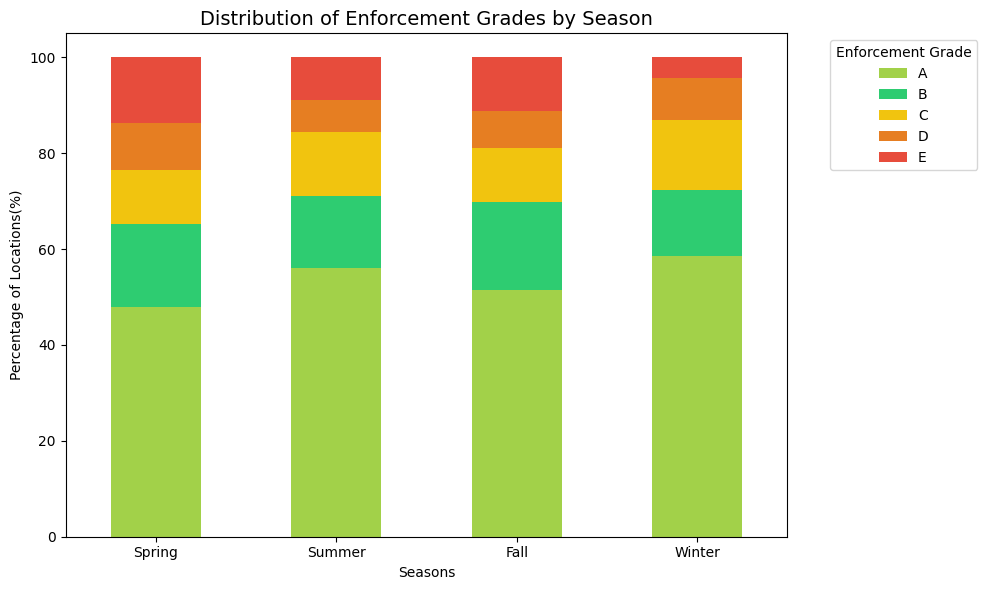

In [13]:
# PLOT: DISTRIBUTION OF ENFORCEMENT GRADES BY SEASON
# What is the overall pattern of enforcement look in terms of season and location. Is a season more risky to park than others?

# Defining the order for seasons of a year to ensure the plot is chronological
seasons = ['Spring','Summer', 'Fall', 'Winter']
df['season'] = pd.Categorical(df['season'], categories=seasons, ordered=True)

# To get each enforcement_grade grouped by the seasons
grade_counts_season = df.groupby(['season', 'enforcement_grade'], observed=False).size().unstack(fill_value=0)

# Setting the color palette
risk_palette = {
    'A': '#a2d149', # Light Green
    'B': '#2ecc71', # Medium Green
    'C': '#f1c40f', # Yellow
    'D': '#e67e22', # Orange
    'E': '#e74c3c'  # Red
}


# --- PLOT : Stacked Bar Chart (Proportional) ---
# Calculating the percentage of grades each day
grade_pct_season = grade_counts_season.div(grade_counts_season.sum(axis=1), axis=0) * 100

grade_pct_season.plot(kind='bar', stacked=True, figsize=(10, 6), color=[risk_palette.get(col) for col in grade_pct_season.columns])
plt.title('Distribution of Enforcement Grades by Season', fontsize=14)
plt.ylabel('Percentage of Locations(%)')
plt.xlabel('Seasons')
plt.legend(title='Enforcement Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


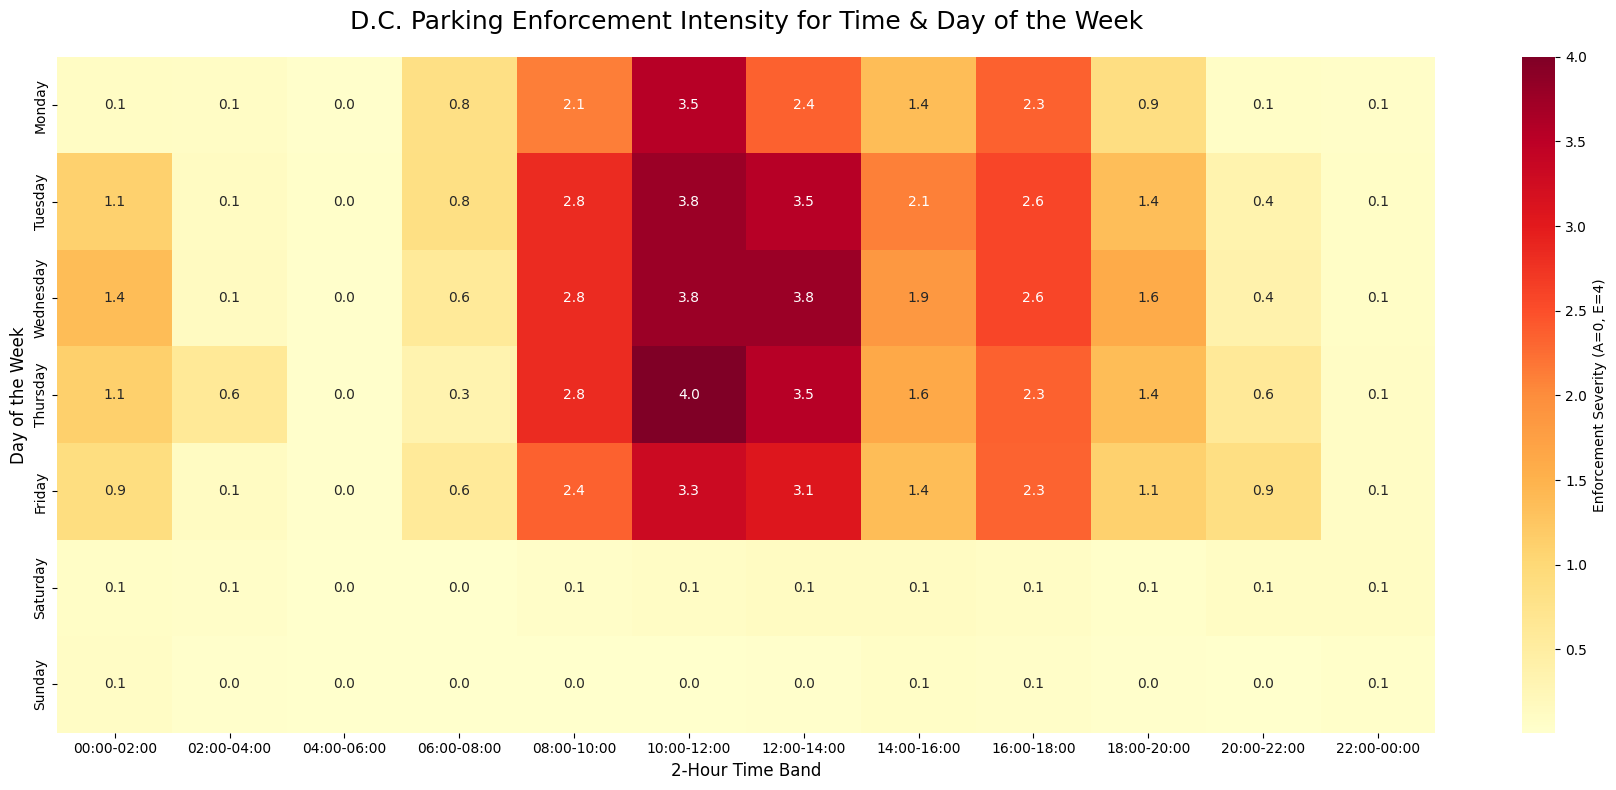

In [14]:
# PLOT 1: D.C. Parking Enforcement Intensity: 2-Hour Windows
# What is the overall parking intesnsity when it comes to Day of the Week & Time in D.C?

# PLOT 2: D.C. Ticket Volume Trends: 2-Hour Intervals
# What is the overall parking ticket volume when it comes to Day of the Week & Time in D.C?

# Mapping Grades to Numbers (A=0 to F=5) to create a Heatmap
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
df['grade_num'] = df['enforcement_grade'].map(grade_map)

# Sorting the Day of the Week & Time Bands
time_order = sorted(df['time_band_label'].unique()) 
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)
df['time_band_label'] = pd.Categorical(df['time_band_label'], categories=time_order, ordered=True)

# Pivoting the data and using 'mean' to find the average enforcement trend of that 2-hour window
heatmap_data = df.pivot_table(
    index='day_of_week', 
    columns='time_band_label', 
    values='grade_num', 
    aggfunc='mean',
    observed=False
)

# Calculating 'total_tickets' by time and day
volume_data = df.groupby(['time_band_label', 'day_of_week'], observed=False)['total_tickets'].sum().reset_index()

#-----PLOT 1-------
# Plotting the data in wide format for heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Enforcement Severity (A=0, E=4)'}
)

plt.title('D.C. Parking Enforcement Intensity for Time & Day of the Week', fontsize=18, pad=20)
plt.xlabel('2-Hour Time Band', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.tight_layout()
plt.show()

#-----PLOT 2------- 
# #Uncomment to see the distribution by ticket volume
# #Plotting the data as Time series 
# plt.figure(figsize=(14, 7))
# sns.lineplot(
#     data=volume_data, 
#     x='time_band_label', 
#     y='total_tickets', 
#     hue='day_of_week', 
#     marker='o',
#     palette='tab10' # Professional and readable palette
# )

# plt.title('D.C. Ticket Volume Trends for Time & Day of the Week', fontsize=16, pad=15)
# plt.ylabel('Total Tickets Issued', fontsize=12)
# plt.xlabel('Time Band (2-Hour Windows)', fontsize=12)
# plt.xticks(rotation=45) # Rotate for better fit of time labels
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Analysis of Location

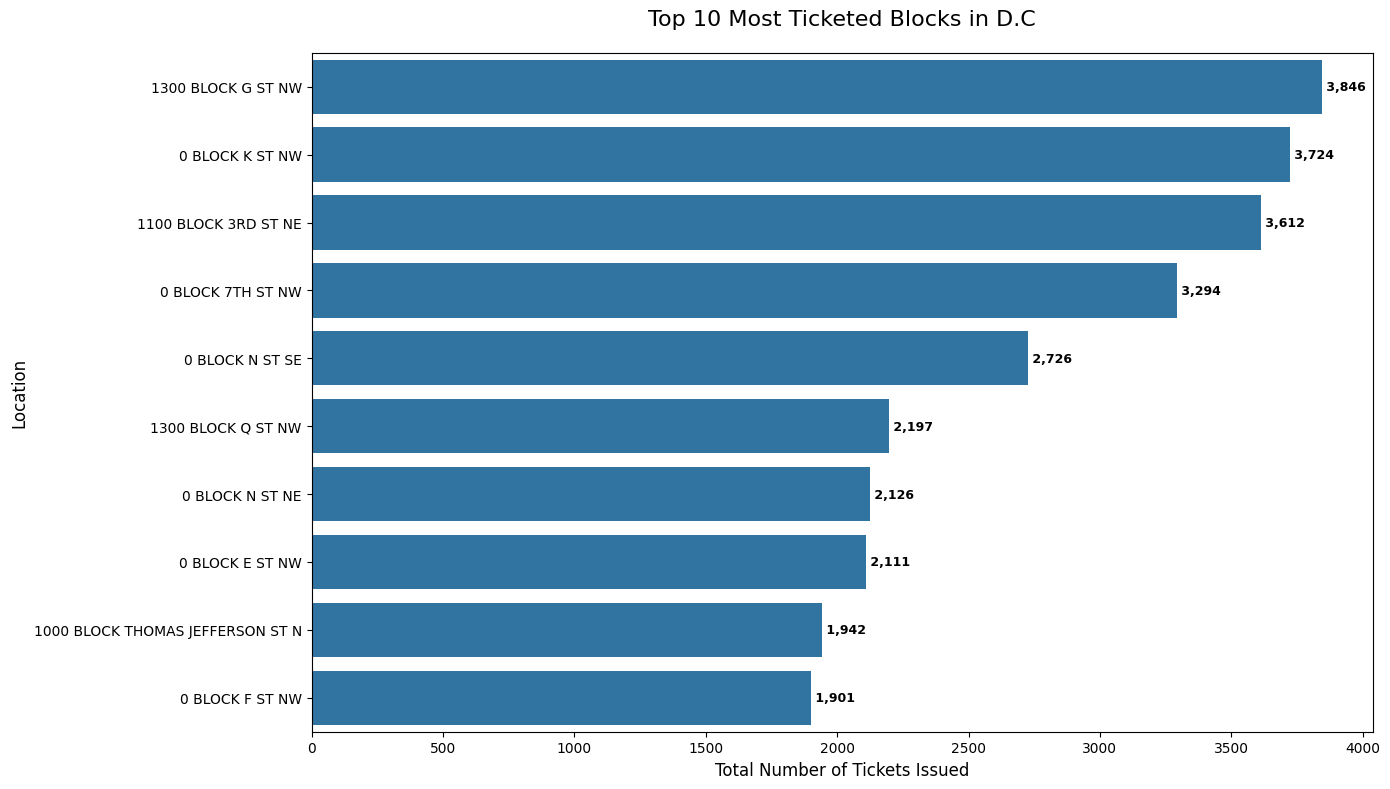

In [15]:
# PLOT: D.C. Parking Enforcement Volume: Location
# What are the most ticketed locations in D.C?

# Aggregating the total ticket volume by block
top_10_blocks = (
    df.groupby('clean_location_block')['total_tickets']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plotting the horizontal bar chart
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_10_blocks, 
    x='total_tickets', 
    y='clean_location_block', 
    legend=False
)

# Formatting
plt.title('Top 10 Most Ticketed Blocks in D.C', fontsize=16, pad=20)
plt.xlabel('Total Number of Tickets Issued', fontsize=12)
plt.ylabel('Location', fontsize=12)

# Adding data labels to the end of the bars for precision
for index, value in enumerate(top_10_blocks['total_tickets']):
    plt.text(value, index, f' {int(value):,}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

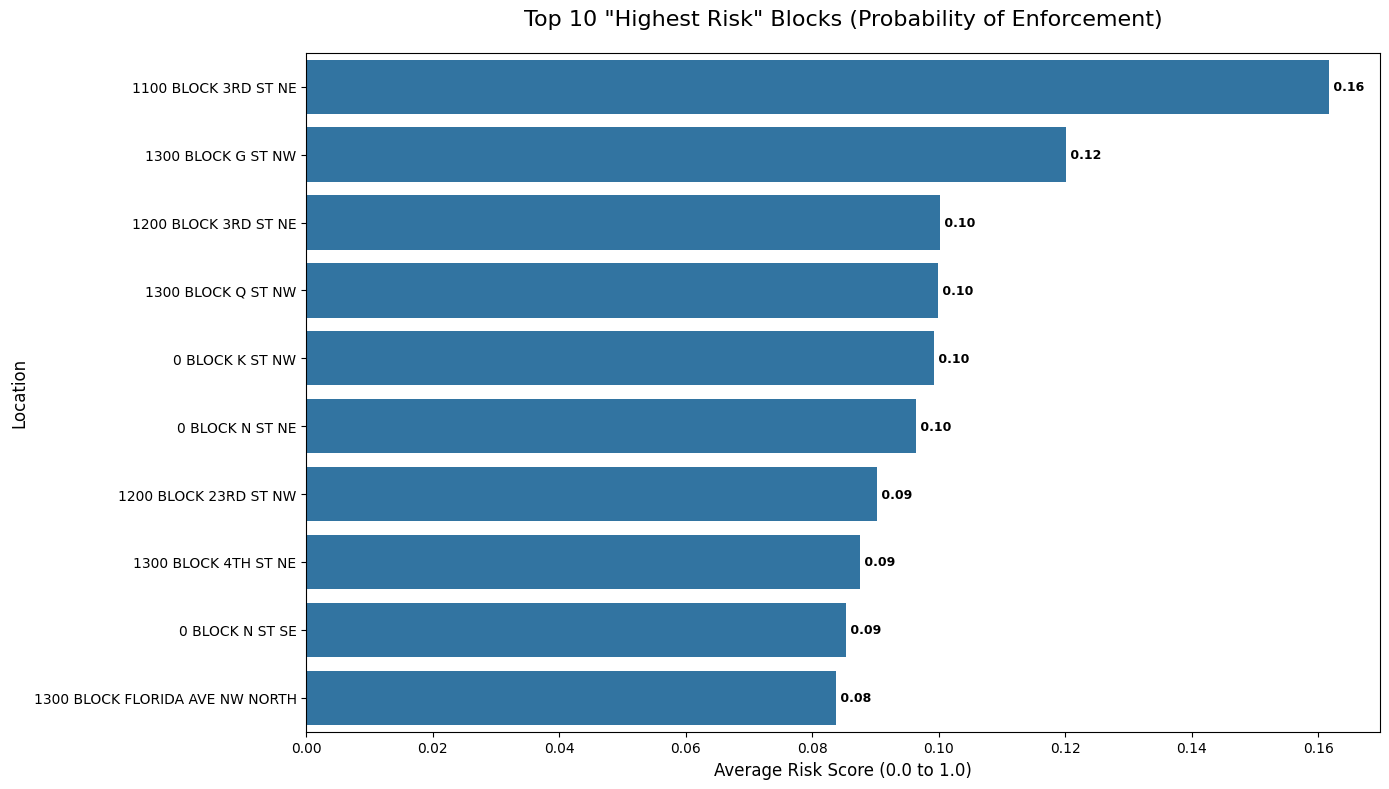

In [16]:
# PLOT: D.C. Parking Enforcement Volume: Location
# What are the most riskiest locations to park in D.C based on enforcement risk?

# Using the'posterior_recurrence_score' as it is the most accurate risk metric to calculate the Top 10 blocks
top_10_risk = (
    df.groupby('clean_location_block')['posterior_recurrence_score']
    .mean() #  'average risk' of that block
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plotting the Risk Chart
plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_10_risk, 
    x='posterior_recurrence_score', 
    y='clean_location_block', 
    legend=False
)

# Formatting
plt.title('Top 10 "Highest Risk" Blocks (Probability of Enforcement)', fontsize=16, pad=20)
plt.xlabel('Average Risk Score (0.0 to 1.0)', fontsize=12)
plt.ylabel('Location', fontsize=12)

# Adding value labels
for index, value in enumerate(top_10_risk['posterior_recurrence_score']):
    plt.text(value, index, f' {value:.2f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis using Wards

/var/folders/61/3sg465kn1qqdy5pb3c7y3sg80000gn/T/ipykernel_59669/1844062402.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(ward_map.geometry.centroid.x, ward_map.geometry.centroid.y, ward_map['WARD']):


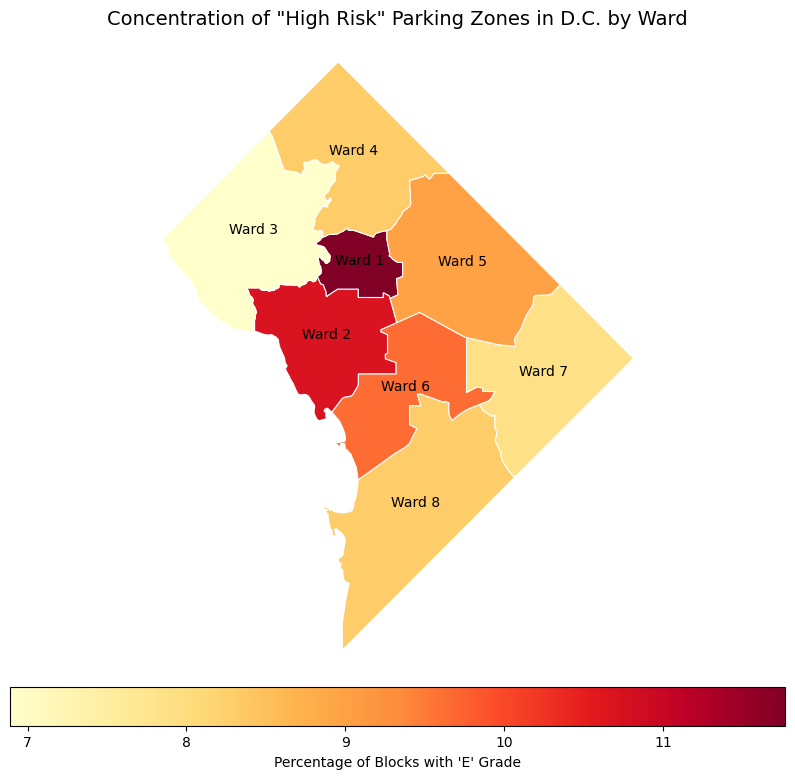

In [17]:
# PLOT Concentration of "High Risk" Parking Zones by D.C. Ward
# Which wards are considered 'High Risk' when it comes to parking enforcement in D.C?

# Loading the GEOJSON file with the information of wards (Downloaded from Open Data DC)
wards = gpd.read_file('Wards_from_2022.geojson')

# Converting the df to GeoDataFrame
gdf = gpd.GeoDataFrame(df, 
    geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE),
    crs="EPSG:4326"
)

# Spatial Join to match the datapoints to the Wards
gdf_wards = gpd.sjoin(gdf, wards, how="left", predicate="within")

# Creating a Ward Level Grade Summary
# This counts how many of each grade (A-E) are in each Ward
ward_summary = gdf_wards.groupby(['WARD', 'enforcement_grade']).size().unstack(fill_value=0)

# Calculating % of high-risk zones (Grade E)
ward_summary['high_risk'] = (ward_summary['E'] / ward_summary.sum(axis=1)) * 100

# Merging the summary data back to the map shapes
ward_map = wards.merge(ward_summary.reset_index(), on='WARD')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plotting by % of Grade F blocks
ward_map.plot(
    column='high_risk', 
    cmap='YlOrRd', # Yellow to Red
    legend=True,
    edgecolor='white',
    linewidth=0.8,
    ax=ax,
    legend_kwds={'label': "Percentage of Blocks with 'E' Grade",'orientation': "horizontal", 'pad': 0.01}
)

# Adding Ward numbers to the map
for x, y, label in zip(ward_map.geometry.centroid.x, ward_map.geometry.centroid.y, ward_map['WARD']):
    ax.text(x, y, f"Ward {label}", fontsize=10, ha='center')
    
plt.title('Concentration of "High Risk" Parking Zones in D.C. by Ward', fontsize=14)
plt.axis('off')
plt.show()

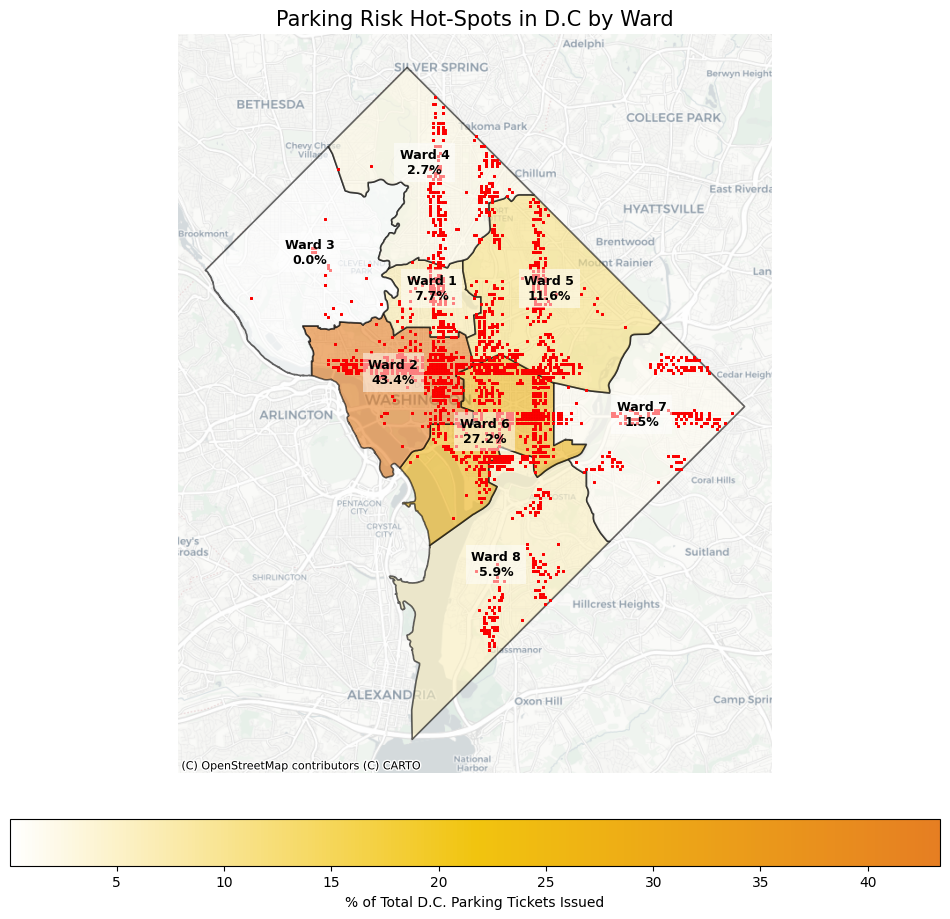

In [18]:
# PLOT Parking Enforcement by Ward
# Which areas are high-risk when it comes to parking enforcement? How do the wards compare to each other in terms of ticket_volume perc?

# Converting the df to GeoDataFrame
gdf_points = gpd.GeoDataFrame(df, 
    geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE),
    crs="EPSG:4326"
)

# Assigning a color palette for the wards
custom_grey_orange = mcolors.LinearSegmentedColormap.from_list(
    "neutral_wrap", ["#ffffff", "#f1c40f", "#e67e22"]) # White - Yellow - Orange ---> intensity
    
# Loading the wards file
wards = gpd.read_file('Wards_from_2022.geojson').to_crs(epsg=3857)
gdf_points = gdf_points.to_crs(epsg=3857)

# Spatial Join to match the datapoints to the Wards
gdf_joined = gpd.sjoin(gdf_points, wards, how="left", predicate="within")

# Summing total_tickets per Ward using total_tickets in each block belonging to a particular Ward
ward_volume = gdf_joined.groupby('WARD')['total_tickets'].sum().reset_index(name='ward_ticket_sum')

# Calculating the total_tickets city wide
city_wide_total = ward_volume['ward_ticket_sum'].sum()

# Calculating ticket_percenatge per ward (Ward Total / City Total) * 100
ward_volume['percentage'] = (ward_volume['ward_ticket_sum'] / city_wide_total) * 100

# Merging back to Ward polygons
ward_map = wards.merge(ward_volume, on='WARD')

# Plotting the data
fig, ax = plt.subplots(figsize=(12, 12))

ward_map.plot(
    column='percentage', 
    cmap=custom_grey_orange,
    alpha=0.6,
    edgecolor='black',
    linewidth=1.2,
    legend=True,
    ax=ax,
    legend_kwds={'label': "% of Total D.C. Parking Tickets Issued", 'orientation': "horizontal", 'pad': 0.05}
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# Updating the Labels to show the Percentage of total_tickets by Ward
for idx, row in ward_map.iterrows():
    ax.annotate(
        text=f"Ward {row['WARD']}\n{row['percentage']:.1f}%", 
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', fontsize=9, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
    )

# Highlighting datapoints were the enforcement grade is 'F'
gdf_points[gdf_points['enforcement_grade'] == 'E'].plot(ax=ax, color='red', markersize=0.5, alpha=0.5)

ax.set_axis_off()
plt.title("Parking Risk Hot-Spots in D.C by Ward", fontsize=15)
plt.show()

# 3. Economic Analysis

In [19]:
# # In the EDA it was noted that the ZCTA was missing for certain blocks
# # Loading the file which contains the Zipcodes in DC. (Downloaded from Open Data DC)
zctas = gpd.read_file('Zip_Codes.geojson').to_crs(epsg=3857)
# Seperating data into 'Found' and 'Missing', the missing blocks would likely be in the border of D.C
missing_mask = gdf_points['ZCTA'].isna()
missing_points = gdf_points[missing_mask].copy()
found_points = gdf_points[~missing_mask].copy()

# Performing 'Nearest' join for the missing ones
# This finds and joins the closest ZCTA polygon for the border blocks
resolved_missing = gpd.sjoin_nearest(
    missing_points.to_crs(epsg=3857), 
    zctas.to_crs(epsg=3857), 
    how='left'
)

# Updating the ZCTA column 
missing_points['ZCTA'] = resolved_missing['ZIPCODE'] 

# Recombining the data
new_df = df
new_df = pd.concat([found_points, missing_points])

print(f"Resolved {len(resolved_missing)} border locations.")

Resolved 24192 border locations.


In [ ]:
# Investigating if there are any missing ZCTA in the new_df
# Filtering for rows where ZCTA is null/NaN
missing_blocks = new_df[new_df['ZCTA'].isna()]['clean_location_block'].unique()

# Converting the filtered values to a list and sorting alphabetically
missing_blocks_list = sorted(list(missing_blocks))

# Printing results
print(f"Found {len(missing_blocks_list)} unique blocks with missing ZCTAs:\n")
for block in missing_blocks_list:
    print(f" {block}")

In [33]:
# Testing if data is missing from the new_df
new_df.isna().sum()

location_block                     0
day_of_week                        0
time_band_label                    0
season                             0
n_opportunities                    0
k_ticketed                         0
total_tickets                      0
raw_recurrence_rate                0
prior_mean                         0
alpha                              0
beta                               0
posterior_recurrence_score         0
clean_location_block               0
LOCATION                      419328
enforcement_grade                  0
ZCTA                               0
LATITUDE                           0
LONGITUDE                          0
grade_num                          0
geometry                           0
dtype: int64

## Basis EDA with Economic Data

In [34]:
acs_df = pd.read_csv('../data/acs_data/dc_acs_data.csv')

In [35]:
acs_df.head()

,NAME,population,median_household_income,poverty_universe,below_poverty,gini_index,tenure_universe,renter_occupied,median_gross_rent,median_age,...,renter_share,no_vehicle_share,race_white_share,race_black_share,race_aian_share,race_asian_share,hispanic_share,drive_alone_share,public_transit_share,worked_from_home_share
0,ZCTA5 20001,44616,138059,42059,5685,0.4671,23868,15890,2499,32.6,...,0.665745,0.414530,0.475838,0.306616,0.002040,0.078806,0.109557,0.194176,0.163515,0.161974
1,ZCTA5 20002,72397,120337,71056,10122,0.4685,35515,21907,2212,33.4,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598
2,ZCTA5 20003,37482,159846,35213,2392,0.4275,19858,12512,2698,34.7,...,0.630074,0.316850,0.631770,0.228270,0.004135,0.047223,0.070327,0.216675,0.240034,0.126648
3,ZCTA5 20004,1831,184792,1831,50,0.3982,1274,731,2997,42.2,...,0.573783,0.499215,0.776625,0.099399,0.000000,0.048061,0.081376,0.087190,0.138162,0.380282
4,ZCTA5 20005,13131,116724,13054,1182,0.4722,8667,5938,2298,34.9,...,0.685127,0.613130,0.602696,0.091844,0.023151,0.088569,0.186353,0.144370,0.128793,0.268072


In [36]:
acs_df.columns

Index(['NAME', 'population', 'median_household_income', 'poverty_universe',
       'below_poverty', 'gini_index', 'tenure_universe', 'renter_occupied',
       'median_gross_rent', 'median_age', 'race_universe', 'race_white',
       'race_black', 'race_aian', 'race_asian', 'hispanic_universe',
       'hispanic', 'commute_universe', 'commute_drove_alone',
       'commute_carpool', 'commute_public_transit', 'commute_worked_from_home',
       'labor_force', 'unemployed', 'households', 'households_no_vehicle',
       'zip code tabulation area', 'poverty_rate', 'unemployment_rate',
       'renter_share', 'no_vehicle_share', 'race_white_share',
       'race_black_share', 'race_aian_share', 'race_asian_share',
       'hispanic_share', 'drive_alone_share', 'public_transit_share',
       'worked_from_home_share'],
      dtype='object')

In [37]:
acs_df.isna().sum()

NAME                        0
population                  0
median_household_income     0
poverty_universe            0
below_poverty               0
gini_index                  0
tenure_universe             0
renter_occupied             0
median_gross_rent           0
median_age                  0
race_universe               0
race_white                  0
race_black                  0
race_aian                   0
race_asian                  0
hispanic_universe           0
hispanic                    0
commute_universe            0
commute_drove_alone         0
commute_carpool             0
commute_public_transit      0
commute_worked_from_home    0
labor_force                 0
unemployed                  0
households                  0
households_no_vehicle       0
zip code tabulation area    0
poverty_rate                0
unemployment_rate           0
renter_share                0
no_vehicle_share            0
race_white_share            0
race_black_share            0
race_aian_

In [25]:
acs_df.describe()

,population,median_household_income,poverty_universe,below_poverty,gini_index,tenure_universe,renter_occupied,median_gross_rent,median_age,race_universe,...,renter_share,no_vehicle_share,race_white_share,race_black_share,race_aian_share,race_asian_share,hispanic_share,drive_alone_share,public_transit_share,worked_from_home_share
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,...,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,30539.681818,119055.318182,29720.772727,4587.727273,0.495018,14744.045455,8622.772727,2043.181818,36.086364,30539.681818,...,0.578508,0.394843,0.449763,0.328995,0.005069,0.070456,0.117531,0.258482,0.189499,0.140241
std,20981.559365,48736.951943,20785.566127,4882.660381,0.047755,9609.743629,6294.113228,482.874393,4.552477,20981.559365,...,0.159971,0.187447,0.242827,0.283499,0.006059,0.087797,0.058494,0.130619,0.059608,0.163398
min,1362.000000,35011.000000,922.000000,50.000000,0.398200,729.000000,686.000000,1222.000000,24.500000,1362.000000,...,0.226763,0.151491,0.027248,0.062975,0.000000,0.002477,0.030544,0.032755,0.073218,0.006422
25%,15711.750000,101449.000000,15503.250000,1315.000000,0.467450,7851.000000,3956.750000,1724.000000,33.850000,15711.750000,...,0.448166,0.248040,0.243929,0.092002,0.001330,0.026011,0.085017,0.156821,0.138665,0.027941
50%,27018.000000,115425.000000,26310.500000,2543.000000,0.493000,13160.500000,6392.500000,2172.500000,35.000000,27018.000000,...,0.617171,0.382472,0.456134,0.221671,0.002642,0.055312,0.100121,0.237320,0.194000,0.074738
75%,43692.000000,140261.750000,41499.500000,5628.750000,0.517625,22171.750000,13377.500000,2330.250000,38.975000,43692.000000,...,0.675028,0.474005,0.658711,0.507787,0.006243,0.075657,0.118865,0.364317,0.233036,0.161312
max,72397.000000,250001.000000,71056.000000,16467.000000,0.631800,35515.000000,21907.000000,2997.000000,45.700000,72397.000000,...,0.941015,0.920439,0.776625,0.908160,0.023151,0.424376,0.279961,0.453612,0.308558,0.678227


In [38]:
acs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   NAME                      22 non-null     object 
 1   population                22 non-null     int64  
 2   median_household_income   22 non-null     int64  
 3   poverty_universe          22 non-null     int64  
 4   below_poverty             22 non-null     int64  
 5   gini_index                22 non-null     float64
 6   tenure_universe           22 non-null     int64  
 7   renter_occupied           22 non-null     int64  
 8   median_gross_rent         22 non-null     int64  
 9   median_age                22 non-null     float64
 10  race_universe             22 non-null     int64  
 11  race_white                22 non-null     int64  
 12  race_black                22 non-null     int64  
 13  race_aian                 22 non-null     int64  
 14  race_asian  

In [27]:
# Standaridizing Join columns for both datasets
new_df['ZCTA'] = new_df['ZCTA'].astype(str).str.strip().str.replace('.0', '', regex=False)
acs_df['zip code tabulation area'] = acs_df['zip code tabulation area'].astype(str).str.strip().str.replace('.0', '', regex=False)

# 3. Perform the Merge
# We use 'left_on' and 'right_on' because the column names differ slightly
merged_df = pd.merge(
    new_df, 
    acs_df, 
    left_on='ZCTA',                     
    right_on='zip code tabulation area', 
    how='left'                          # Keep all ticket data
)

# Dropping identical column
merged_df = merged_df.drop(columns=['zip code tabulation area'])


In [39]:
merged_df.columns

Index(['location_block', 'day_of_week', 'time_band_label', 'season',
       'n_opportunities', 'k_ticketed', 'total_tickets', 'raw_recurrence_rate',
       'prior_mean', 'alpha', 'beta', 'posterior_recurrence_score',
       'clean_location_block', 'LOCATION', 'enforcement_grade', 'ZCTA',
       'LATITUDE', 'LONGITUDE', 'grade_num', 'geometry', 'NAME', 'population',
       'median_household_income', 'poverty_universe', 'below_poverty',
       'gini_index', 'tenure_universe', 'renter_occupied', 'median_gross_rent',
       'median_age', 'race_universe', 'race_white', 'race_black', 'race_aian',
       'race_asian', 'hispanic_universe', 'hispanic', 'commute_universe',
       'commute_drove_alone', 'commute_carpool', 'commute_public_transit',
       'commute_worked_from_home', 'labor_force', 'unemployed', 'households',
       'households_no_vehicle', 'poverty_rate', 'unemployment_rate',
       'renter_share', 'no_vehicle_share', 'race_white_share',
       'race_black_share', 'race_aian_share

In [40]:
merged_df.head()

,location_block,day_of_week,time_band_label,season,n_opportunities,k_ticketed,total_tickets,raw_recurrence_rate,prior_mean,alpha,...,renter_share,no_vehicle_share,race_white_share,race_black_share,race_aian_share,race_asian_share,hispanic_share,drive_alone_share,public_transit_share,worked_from_home_share
0,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Fall,13,0,0,0.0,0.003458,0.017289,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598
1,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Spring,13,0,0,0.0,0.003697,0.018483,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598
2,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Summer,13,0,0,0.0,0.002885,0.014423,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598
3,0 BLOCK 10TH ST NE,Friday,00:00-02:00,Winter,13,0,0,0.0,0.003856,0.019279,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598
4,0 BLOCK 10TH ST NE,Friday,02:00-04:00,Fall,13,0,0,0.0,0.002483,0.012417,...,0.616838,0.344699,0.421592,0.386894,0.003232,0.043676,0.089741,0.236577,0.212798,0.079598


In [41]:
merged_df.isna().sum()

location_block                     0
day_of_week                        0
time_band_label                    0
season                             0
n_opportunities                    0
k_ticketed                         0
total_tickets                      0
raw_recurrence_rate                0
prior_mean                         0
alpha                              0
beta                               0
posterior_recurrence_score         0
clean_location_block               0
LOCATION                      419328
enforcement_grade                  0
ZCTA                               0
LATITUDE                           0
LONGITUDE                          0
grade_num                          0
geometry                           0
NAME                            6048
population                      6048
median_household_income         6048
poverty_universe                6048
below_poverty                   6048
gini_index                      6048
tenure_universe                 6048
r

In [42]:
# Filter for rows where the ACS data (NAME) is missing
missing_zctas = merged_df[merged_df['NAME'].isna()]['ZCTA'].unique()

print("These ZCTAs are missing from your ACS data:")
print(missing_zctas)

These ZCTAs are missing from your ACS data:
['20597' '20045' '20565' '20319' '20057' '20250']
